In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import Perceptron
import tensorflow
from tensorflow.keras.utils import to_categorical

In [23]:
from sklearn.datasets import fetch_openml


print("Downloading MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=True)

df = mnist.frame
print(df.head())

X, y = mnist["data"], mnist["target"]


   pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  pixel9  \
0       0       0       0       0       0       0       0       0       0   
1       0       0       0       0       0       0       0       0       0   
2       0       0       0       0       0       0       0       0       0   
3       0       0       0       0       0       0       0       0       0   
4       0       0       0       0       0       0       0       0       0   

   pixel10  ...  pixel776  pixel777  pixel778  pixel779  pixel780  pixel781  \
0        0  ...         0         0         0         0         0         0   
1        0  ...         0         0         0         0         0         0   
2        0  ...         0         0         0         0         0         0   
3        0  ...         0         0         0         0         0         0   
4        0  ...         0         0         0         0         0         0   

   pixel782  pixel783  pixel784  class  
0         0         0

In [24]:
df

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,class
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
69996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
69997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
69998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5


In [27]:
df['class'].value_counts()

,count
class,
1,7877
7,7293
3,7141
2,6990
9,6958
0,6903
6,6876
8,6825
4,6824


In [29]:
X_train = df.drop('class', axis=1).values
y_train = df['class'].values
X_test = X_train
y_test = y_train

In [30]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test .astype('float32')/ 255.0

# **ANN**

ANN with single layers

In [35]:
X_train_img = X_train.reshape(-1,28,28)
X_test_img = X_test.reshape(-1,28,28)

In [34]:
y_train_cat = to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10)

In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout


In [38]:
perceptron = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [39]:
perceptron.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

In [40]:
hist_percep = perceptron.fit(X_train_img, y_train_cat, epochs=10, batch_size=32,validation_data=(X_test_img, y_test_cat), verbose=1)

Epoch 1/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8285 - loss: 0.7277 - val_accuracy: 0.8774 - val_loss: 0.4777
Epoch 2/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8855 - loss: 0.4356 - val_accuracy: 0.8919 - val_loss: 0.4045
Epoch 3/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8949 - loss: 0.3877 - val_accuracy: 0.8981 - val_loss: 0.3724
Epoch 4/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9006 - loss: 0.3635 - val_accuracy: 0.9026 - val_loss: 0.3538
Epoch 5/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9040 - loss: 0.3483 - val_accuracy: 0.9061 - val_loss: 0.3411
Epoch 6/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9069 - loss: 0.3373 - val_accuracy: 0.9073 - val_loss: 0.3320
Epoch 7/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9089 - loss: 0.3292 - val_accuracy: 0.9096 - val_loss: 0.3247
Epoch 8/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9103 - loss: 0.3227 - 

In [43]:
acc = perceptron.evaluate(X_test_img, y_test_cat, verbose=0)
acc

[0.3097686767578125, 0.9138285517692566]

ANN With Multiple Layers

In [44]:
perceptron1 = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(150, activation='relu'),
    Dense(100, activation='relu'),
    Dense(50, activation='relu'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [45]:
perceptron1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [47]:
hist_percep1 = perceptron1.fit(X_train_img, y_train_cat, epochs=5, batch_size=32,validation_data=(X_test_img, y_test_cat), verbose=1)

Epoch 1/5
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.9629 - loss: 0.1200 - val_accuracy: 0.9746 - val_loss: 0.0809
Epoch 2/5
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.9760 - loss: 0.0771 - val_accuracy: 0.9813 - val_loss: 0.0584
Epoch 3/5
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9815 - loss: 0.0579 - val_accuracy: 0.9889 - val_loss: 0.0370
Epoch 4/5
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.9854 - loss: 0.0457 - val_accuracy: 0.9896 - val_loss: 0.0325
Epoch 5/5
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.9883 - loss: 0.0363 - val_accuracy: 0.9914 - val_loss: 0.0262


In [48]:
acc1 = perceptron1.evaluate(X_test_img, y_test_cat, verbose=0)
acc1

[0.0262431837618351, 0.991357147693634]

# **CNN**

In [49]:
X_train_cnn = X_train.reshape(-1,28,28,1)
X_test_cnn = X_test.reshape(-1,28,28,1)

In [53]:
cnn = Sequential([
    Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(150, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [54]:
cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [56]:
history_cnn = cnn.fit(X_train_cnn, y_train_cat, epochs=5, batch_size=32,validation_data=(X_test_cnn, y_test_cat), verbose=1)

Epoch 1/5
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 67s 31ms/step - accuracy: 0.9761 - loss: 0.0800 - val_accuracy: 0.9901 - val_loss: 0.0313
Epoch 2/5
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 67s 31ms/step - accuracy: 0.9831 - loss: 0.0537 - val_accuracy: 0.9927 - val_loss: 0.0235
Epoch 3/5
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 80s 30ms/step - accuracy: 0.9874 - loss: 0.0416 - val_accuracy: 0.9948 - val_loss: 0.0159
Epoch 4/5
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 64s 29ms/step - accuracy: 0.9895 - loss: 0.0334 - val_accuracy: 0.9962 - val_loss: 0.0122
Epoch 5/5
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 65s 30ms/step - accuracy: 0.9915 - loss: 0.0283 - val_accuracy: 0.9977 - val_loss: 0.0084


In [57]:
acc_cnn = cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)
acc_cnn

[0.008384165354073048, 0.9976999759674072]

### Visualization of Single-Layer Perceptron (ANN) Training History

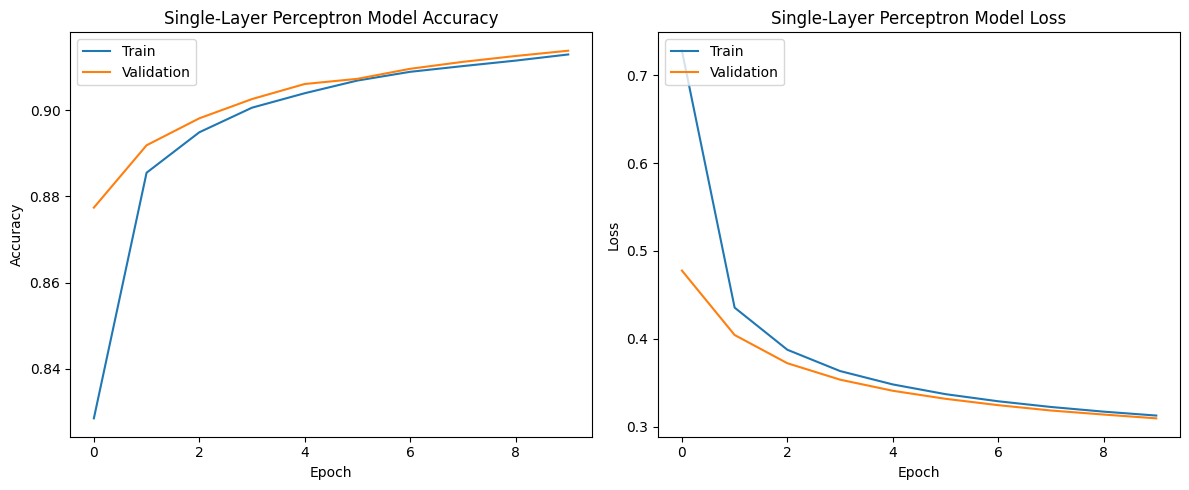

In [62]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(hist_percep.history['accuracy'])
plt.plot(hist_percep.history['val_accuracy'])
plt.title('Single-Layer Perceptron Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(hist_percep.history['loss'])
plt.plot(hist_percep.history['val_loss'])
plt.title('Single-Layer Perceptron Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

### Visualization of Multi-Layer Perceptron (ANN) Training History

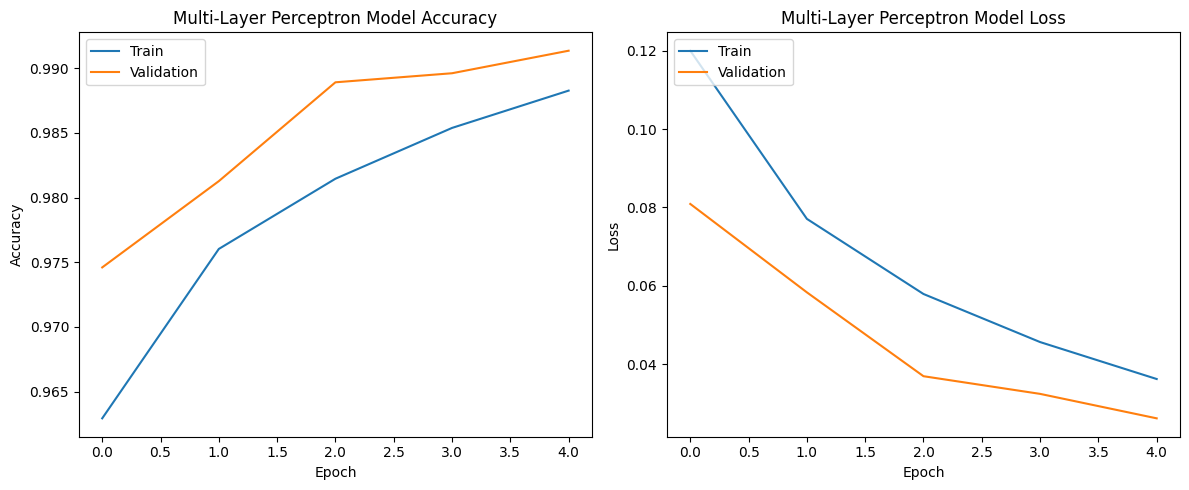

In [63]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(hist_percep1.history['accuracy'])
plt.plot(hist_percep1.history['val_accuracy'])
plt.title('Multi-Layer Perceptron Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(hist_percep1.history['loss'])
plt.plot(hist_percep1.history['val_loss'])
plt.title('Multi-Layer Perceptron Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

### Visualization of CNN Training History

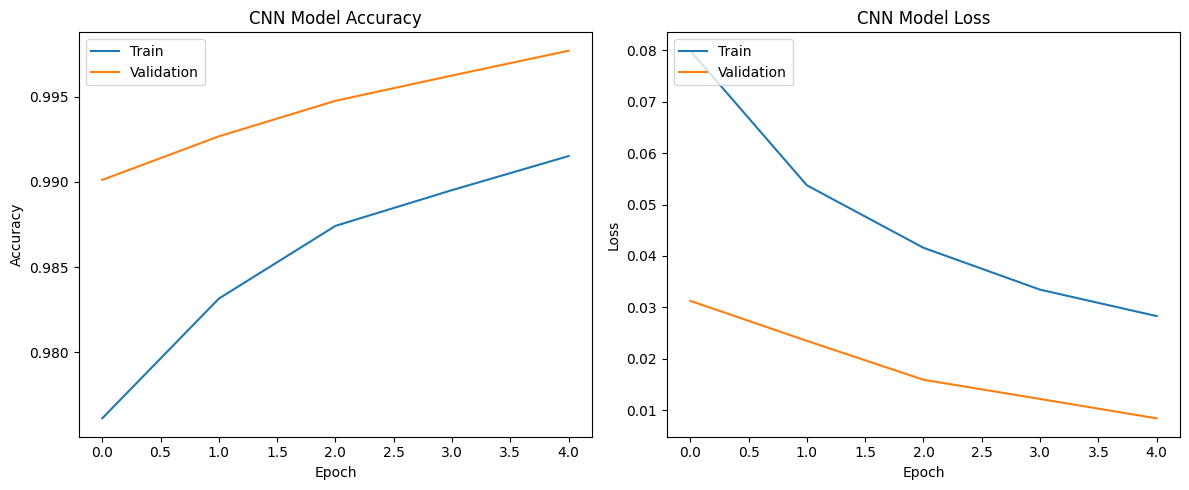

In [64]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['val_accuracy'])
plt.title('CNN Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'])
plt.plot(history_cnn.history['val_loss'])
plt.title('CNN Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

### Comparison of Model Accuracies

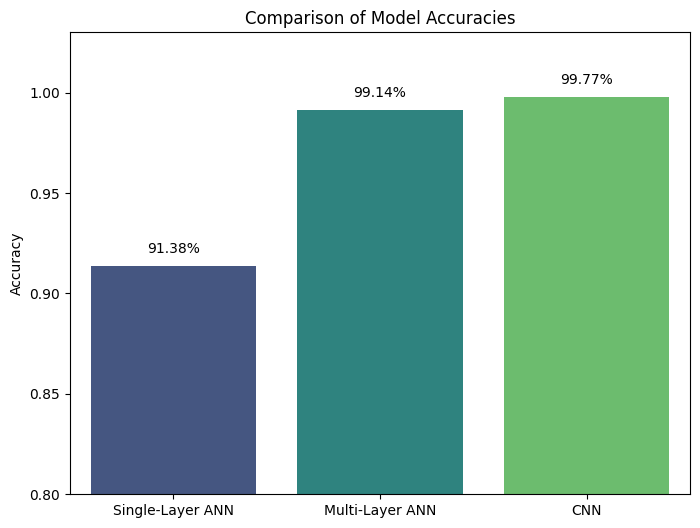

In [70]:
models = ['Single-Layer ANN', 'Multi-Layer ANN', 'CNN']
accuracies = [acc[1], acc1[1], acc_cnn[1]]

plt.figure(figsize=(8, 6))
sns.barplot(x=models, y=accuracies, palette='viridis', hue=models, legend=False)
plt.title('Comparison of Model Accuracies')
plt.ylabel('Accuracy')
plt.ylim(0.8, 1.03) # Adjusted y-axis limit for better label visibility

# Add percentage labels on top of the bars
for index, value in enumerate(accuracies):
    plt.text(index, value + 0.005, f'{value:.2%}', ha='center', va='bottom') # Format as percentage

plt.show()